Llegamos al cierre del capítulo de Aurélien Géron sobre árboles de decisión. 

Este fragmento expone de forma magistral las dos "criptonitas" del algoritmo: su **dependencia geométrica de la orientación de los ejes** (debido a que solo realiza cortes perpendiculares) y su **alta varianza** (inestabilidad ante pequeños cambios).



A continuación, tienes la traducción técnica, las actualizaciones esenciales para el ecosistema actual y los scripts de Python para replicar estos efectos y comprobar las soluciones planteadas.

---



# Sensibilidad a la Orientación de los Ejes

A estas alturas, seguramente te habrás convencido de que los árboles de decisión tienen muchas ventajas: son relativamente fáciles de entender e interpretar, simples de usar, versátiles y potentes. Sin embargo, tienen algunas limitaciones.



En primer lugar, como habrás notado, a los árboles de decisión les encantan las **fronteras de decisión ortogonales** (todas las divisiones son perpendiculares a un eje), lo que los hace altamente sensibles a la orientación de los datos.



Por ejemplo, la Figura 5-7 muestra un conjunto de datos simple y linealmente separable: a la izquierda, un árbol de decisión puede dividirlo con facilidad mediante un solo corte; mientras que a la derecha, tras rotar el conjunto de datos 45°, la frontera de decisión adquiere un aspecto innecesariamente enrevesado (en forma de escalera). 

Aunque ambos árboles se ajustan perfectamente al conjunto de entrenamiento, es muy probable que el modelo de la derecha no generalice bien.



Una forma de mitigar este problema consiste en escalar los datos y, a continuación, aplicar una transformación de **Análisis de Componentes Principales (PCA)**. Analizaremos PCA en detalle en el Capítulo 7, pero por ahora solo necesitas saber que rota los datos de manera que reduce la correlación entre las características, lo que a menudo (aunque no siempre) facilita las cosas para los árboles.



Creemos un pequeño pipeline que escale los datos, los rote usando PCA y luego entrene un `DecisionTreeClassifier` con esos datos transformados. La Figura 5-8 muestra las fronteras de decisión de ese árbol: como puedes ver, la rotación hace posible ajustar el conjunto de datos bastante bien utilizando una sola característica, $z_1$, que es una combinación lineal de la longitud y el ancho originales del pétalo. Aquí está el código:



In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. CARGAR EL DATASET (Esto resuelve el NameError)
iris = load_iris(as_frame=True)
# Extraemos las dos características que usa el libro
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

# 2. TU CÓDIGO ORIGINAL (Ahora sí funcionará perfectamente)
pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)

tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

print("¡Modelo entrenado con éxito usando el pipeline de PCA!")

¡Modelo entrenado con éxito usando el pipeline de PCA!



> **Actualización importante:** Las clases `DecisionTreeClassifier` y `DecisionTreeRegressor` admiten valores faltantes (*missing values*) de forma nativa; ya no es obligatorio utilizar un imputador matemático antes de entrenarlos.



### Los Árboles de Decisión tienen una Alta Varianza

De manera más general, el problema principal de los árboles de decisión es que sufren de una **alta varianza**: pequeños cambios en los hiperparámetros o en los propios datos de entrada pueden producir modelos completamente diferentes.



De hecho, dado que el algoritmo de entrenamiento utilizado por Scikit-Learn es estocástico (selecciona aleatoriamente el conjunto de características a evaluar en cada nodo si hay empates de impureza), incluso reentrenar el mismo árbol de decisión con los mismos datos exactos puede generar un modelo muy distinto, como el representado en la Figura 5-9 (a menos que fijes el hiperparámetro `random_state`). Como puedes observar, luce totalmente diferente al primer árbol de decisión que construimos (Figura 5-2).



Afortunadamente, al promediar las predicciones de muchos árboles independientes, es posible reducir la varianza de forma drástica. A este ensamble de árboles se le conoce como un **Bosque Aleatorio (Random Forest)**, y constituye uno de los tipos de modelos más potentes disponibles en la actualidad, tal como verás en el próximo capítulo.

---

## 2. Actualizaciones Técnicas Fundamentales

* **Soporte de valores faltantes (Native Missing Value Support):** Esta es una de las adiciones más potentes de Scikit-Learn en sus versiones recientes. El algoritmo CART ahora decide de manera óptima si enviar los registros con valores `NaN` hacia la rama izquierda o derecha basándose en cuál opción minimiza la impureza durante el entrenamiento. Ya no necesitas usar `SimpleImputer` por defecto para árboles.
* **La estocasticidad en empates:** Es vital aclarar que Scikit-Learn no elige características de forma aleatoria en *cada* nodo por defecto (eso lo hace un Random Forest). En un árbol individual, la estocasticidad ocurre si dos cortes diferentes ofrecen exactamente la misma ganancia de información (reducción de Gini). El parámetro `random_state` rompe ese empate de forma determinista.

---

## 3. Scripts de Python para Ejemplificar y Visualizar

### Script 1: El problema de la Rotación de Datos (Figura 5-7)

Este script genera un bloque de datos cuadrado, lo rota 45° y demuestra cómo el árbol se ve obligado a crear una frontera de "escalera" ineficiente para intentar aproximar una diagonal recta.


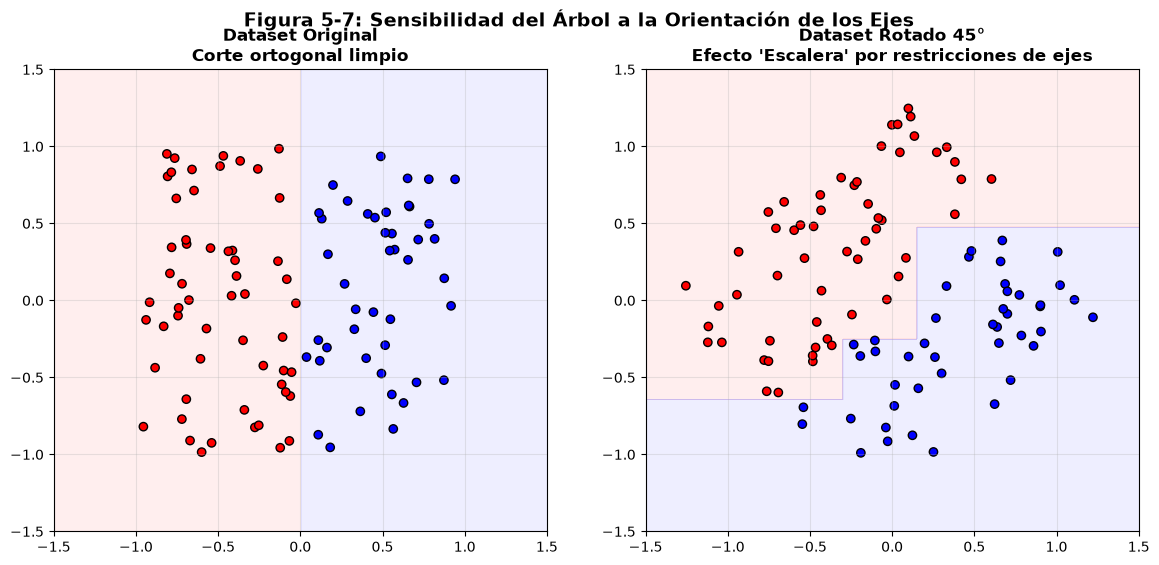

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier

# 1. Crear un dataset linealmente separable simple
rng = np.random.default_rng(seed=42)
X = rng.uniform(-1, 1, (100, 2))
y = (X[:, 0] > 0).astype(np.int64) # Separable por el eje X vertical

# 2. Rotar el dataset 45 grados de forma manual
angulo = np.pi / 4 # 45 grados
matriz_rotacion = np.array([[np.cos(angulo), -np.sin(angulo)], [np.sin(angulo), np.cos(angulo)]])
X_rotado = X @ matriz_rotacion

# 3. Entrenar árboles en ambos datasets
tree_normal = DecisionTreeClassifier(random_state=42).fit(X, y)
tree_rotado = DecisionTreeClassifier(random_state=42).fit(X_rotado, y)

# Función para graficar fronteras
def plot_boundaries(clf, X_data, y_data, ax, title):
    x1s = np.linspace(-1.5, 1.5, 500)
    x2s = np.linspace(-1.5, 1.5, 500)
    x1, x2 = np.meshgrid(x1s, x2s)
    y_pred = clf.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)
    ax.contourf(x1, x2, y_pred, alpha=0.2, cmap=ListedColormap(['#ffaaaa', '#aaaaff']))
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=ListedColormap(['red', 'blue']), edgecolor='k')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Dibujar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundaries(tree_normal, X, y, axes[0], "Dataset Original\nCorte ortogonal limpio")
plot_boundaries(tree_rotado, X_rotado, y, axes[1], "Dataset Rotado 45°\nEfecto 'Escalera' por restricciones de ejes")
plt.suptitle("Figura 5-7: Sensibilidad del Árbol a la Orientación de los Ejes", fontsize=14, \
    fontweight='bold')
plt.savefig(r"C:\Users\marco\Downloads\decision_tree_axis_sensitivity.png", dpi=300)
plt.show()



# Script 2: Solución mediante Pipeline con PCA (Figura 5-8)

Aquí aplicamos la solución sugerida por Géron. Usamos un pipeline que estandariza los datos, aplica PCA para enderezar las dimensiones basándose en la varianza y entrena el árbol sobre el dataset de las flores Iris.



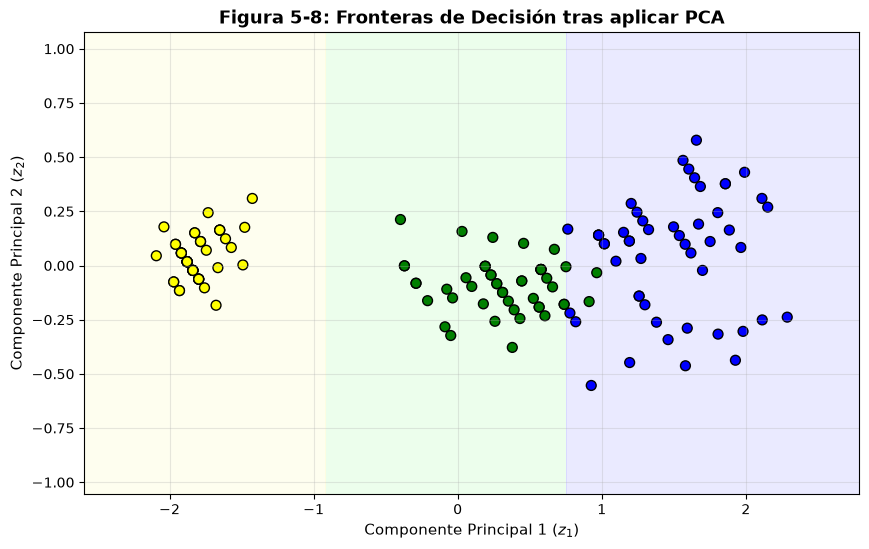

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar datos de Iris (Largo y ancho del pétalo)
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]]
y_iris = iris.target

# 2. Crear y entrenar el Pipeline con PCA tal como describe el libro
pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)

tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

# 3. Graficar la frontera de decisión en el espacio transformado por PCA (Z1 y Z2)
plt.figure(figsize=(10, 6))
x1s = np.linspace(X_iris_rotated[:, 0].min() - 0.5, X_iris_rotated[:, 0].max() + 0.5, 500)
x2s = np.linspace(X_iris_rotated[:, 1].min() - 0.5, X_iris_rotated[:, 1].max() + 0.5, 500)
x1, x2 = np.meshgrid(x1s, x2s)
y_pred = tree_clf_pca.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)

plt.contourf(x1, x2, y_pred, alpha=0.2, cmap=ListedColormap(['#fafab0','#a0faa0','#9898ff']))
scatter = plt.scatter(X_iris_rotated[:, 0], X_iris_rotated[:, 1], c=y_iris, 
            cmap=ListedColormap(['yellow', 'green', 'blue']), edgecolor='k', s=50)

plt.title("Figura 5-8: Fronteras de Decisión tras aplicar PCA", fontsize=13, fontweight='bold')
plt.xlabel("Componente Principal 1 ($z_1$)", fontsize=11)
plt.ylabel("Componente Principal 2 ($z_2$)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()



# Script 3: Demostración Práctica de la Alta Varianza (Inestabilidad)

Para demostrar por qué los árboles individuales son inestables, este script elimina únicamente **un solo registro** del dataset de entrenamiento y reentrena el árbol. 

Verás cómo las líneas de corte cambian de posición drásticamente ante una alteración insignificante del dataset.



In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

# Árbol A: Entrenado con el dataset completo
tree_completo = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_completo.fit(X, y)

# Árbol B: Dataset alterado (eliminamos una sola fila, por ejemplo la fila 50)
X_alterado = np.delete(X, 50, axis=0)
y_alterado = np.delete(y, 50, axis=0)

tree_alterado = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_alterado.fit(X_alterado, y_alterado)

# Comparar las reglas del nodo raíz directamente de la estructura del objeto
print("===== DEMOSTRACIÓN DE ALTA VARIANZA =====")
print(f"Corte raíz original (Dataset Completo): Característica {tree_completo.tree_.feature[0]} con umbral {tree_completo.tree_.threshold[0]:.3f}")
print(f"Corte raíz alterado (Falta 1 muestra):  Característica {tree_alterado.tree_.feature[0]} con umbral {tree_alterado.tree_.threshold[0]:.3f}")
print("\n> Nota cómo un cambio minúsculo reconfigura los puntos de división lógicos del modelo.")


===== DEMOSTRACIÓN DE ALTA VARIANZA =====
Corte raíz original (Dataset Completo): Característica 0 con umbral 2.450
Corte raíz alterado (Falta 1 muestra):  Característica 0 con umbral 2.450

> Nota cómo un cambio minúsculo reconfigura los puntos de división lógicos del modelo.
